In [329]:

import matplotlib.pyplot as plt
import os
import cv2
import usafocus
import numpy as np
from PIL import Image
import yaml

def extract_number(filename):
    # Extract the numeric part from the filename
    return int(''.join(filter(str.isdigit, filename)))


dirtop = r"E:\OFM_EdgeDetection\auto_mtf-main\auto_mtf-main\scans\bayer_08_14_2024-14_52_28_40x_0degree"

all_paths = {}
for i in ["vert","horiz"]:
    print(i)
    directory = os.path.join(dirtop, i)
    paths =  [os.path.join(directory, d) for d in os.listdir(directory) if os.path.isdir(os.path.join(directory, d))]
    all_paths[i] = paths


    # for path in paths:
    #     print(path)
    #     jpeg_files = [f for f in os.listdir(path) if f.endswith('.npz') and os.path.isfile(os.path.join(path, f))]
        
    #     std_devs = []
    #     laplacian = []
    #     derives = []


    #     for image in jpeg_files:
    #         print(image)
    #         img = Image.open(os.path.join(path, image))
    #         numpydata = np.asarray(img)

    #         std_devs.append(usafocus.standard_deviation(numpydata))
    #         laplacian.append(usafocus.edge_laplacian(numpydata))
    #         derives.append(usafocus.measure_derivs(numpydata))

all_paths


vert
horiz


{'vert': ['E:\\OFM_EdgeDetection\\auto_mtf-main\\auto_mtf-main\\scans\\bayer_08_28_2024\\vert\\1_over_6',
  'E:\\OFM_EdgeDetection\\auto_mtf-main\\auto_mtf-main\\scans\\bayer_08_28_2024\\vert\\2_over_6',
  'E:\\OFM_EdgeDetection\\auto_mtf-main\\auto_mtf-main\\scans\\bayer_08_28_2024\\vert\\3_over_6',
  'E:\\OFM_EdgeDetection\\auto_mtf-main\\auto_mtf-main\\scans\\bayer_08_28_2024\\vert\\4_over_6',
  'E:\\OFM_EdgeDetection\\auto_mtf-main\\auto_mtf-main\\scans\\bayer_08_28_2024\\vert\\5_over_6'],
 'horiz': ['E:\\OFM_EdgeDetection\\auto_mtf-main\\auto_mtf-main\\scans\\bayer_08_28_2024\\horiz\\1_over_6',
  'E:\\OFM_EdgeDetection\\auto_mtf-main\\auto_mtf-main\\scans\\bayer_08_28_2024\\horiz\\2_over_6',
  'E:\\OFM_EdgeDetection\\auto_mtf-main\\auto_mtf-main\\scans\\bayer_08_28_2024\\horiz\\3_over_6',
  'E:\\OFM_EdgeDetection\\auto_mtf-main\\auto_mtf-main\\scans\\bayer_08_28_2024\\horiz\\4_over_6',
  'E:\\OFM_EdgeDetection\\auto_mtf-main\\auto_mtf-main\\scans\\bayer_08_28_2024\\horiz\\5_over_6

In [330]:
vert_psfs = np.load(os.path.join(all_paths['vert'][0], "edge_analysis.npz"))

def load_folders(paths):
    return np.concatenate(
        [
            np.load(os.path.join(folder, "edge_analysis.npz"))['psfs']
            for folder in paths
        ],
        axis=0,
    )

vert_psfs = load_folders(all_paths['vert'])
horiz_psfs = load_folders(all_paths['horiz'])
vert_psfs.shape

(5, 30, 9, 3, 2, 799)

The axes are:

1. Indexes through the folders (i.e. transverse positions of the edge)
2. Image in stack (i.e. Z)
3. ROI along line (i.e. Y for a vertical edge)
4. Colour channel
5. 0=X coordinate, 1=intensity
6. Coordinate across edge (i.e. X for a vertical edge), resampled. Set index 5 to 0 to get original pixel coords.

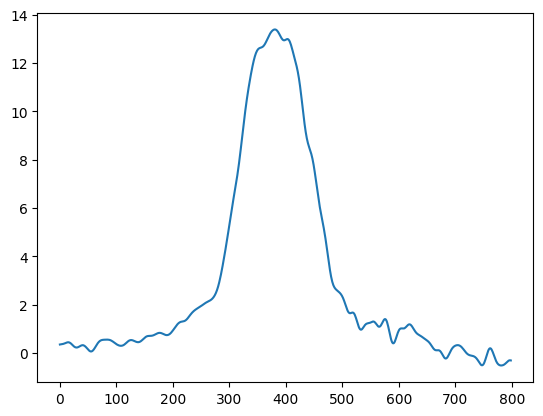

In [331]:
plt.plot(horiz_psfs[0,14,4,1,1,:])

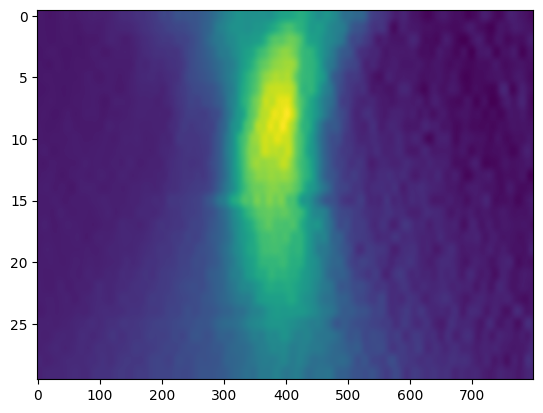

In [332]:
middle_green = horiz_psfs[0,:,4,1,1,:]
middle_green_x = horiz_psfs[0,0,4,1,0,:]
plt.imshow(middle_green, aspect="auto")

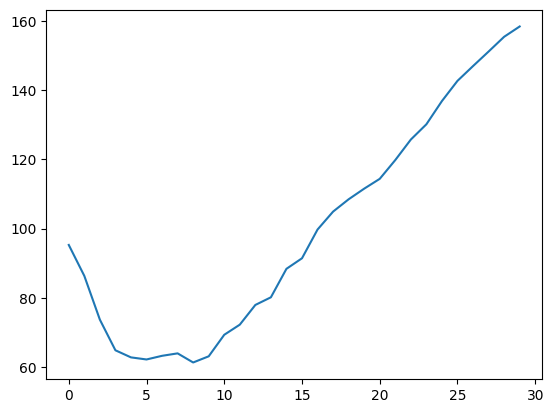

In [333]:
def second_moment(y, axis=0):
    """Calculate the second moment of a 1D function"""
    x = np.arange(y.shape[axis])
    first_moment = np.sum(y*x, axis=axis)/np.sum(y, axis=axis)
    x_sl = [np.newaxis] * len(y.shape)
    x_sl[axis] = slice(None)
    m_sl = [slice(None)] * len(y.shape)
    m_sl[axis] = np.newaxis
    dx = x[tuple(x_sl)] - first_moment[tuple(m_sl)]*np.ones(y.shape)
    second_moment = np.sum(dx**2*y, axis=axis)/np.sum(y, axis=axis)
    return second_moment

widths = np.array([np.sqrt(second_moment(y)) for y in middle_green])
plt.plot(widths)

In [334]:
def bottom_slice(y, N=5, axis=0):
    centre = np.argmin(y, axis=axis)
    margin = (N-1)//2
    centre = max(margin, centre)
    centre = min(y.shape[axis]-margin-1, centre)
    return slice(centre - margin, centre + margin + 1)

def parabolic_minimum_fit(x, y, N=5, axis=0, plot_ax=None):
    s = bottom_slice(y, N=N)
    p = np.polynomial.Polynomial.fit(x[s], y[s], 2)
    minimum = p.deriv().roots()[0]
    if plot_ax:
        xx = np.linspace(np.min(x[s]), np.max(x[s]), 100)
        plot_ax.plot(xx, p(xx))
        plot_ax.axvline(minimum)
    return minimum

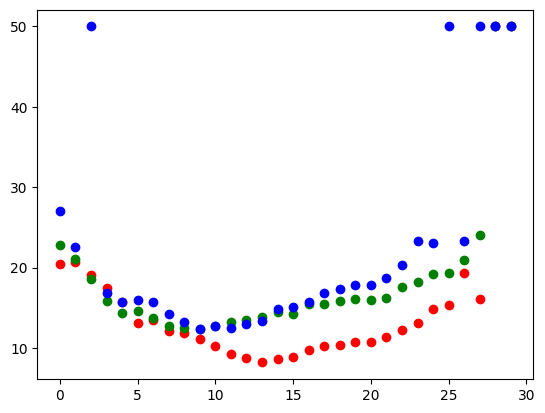

In [335]:
import resolution
import resolution.mo_stub

from resolution.psf_image import find_fwhm

for i, col in enumerate(["red","green","blue"]):
    fwhms = [
        find_fwhm(roi[0,:], roi[1,:])
        for roi in horiz_psfs[0,:,4,i,:,:]
    ]
    plt.plot(fwhms, 'o', color=col)

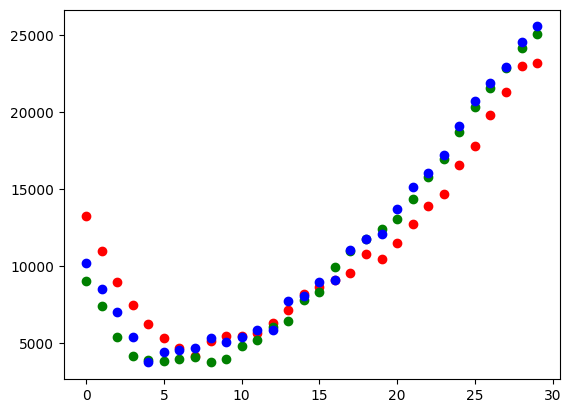

In [336]:

for i, col in enumerate(["red","green","blue"]):
    fwhms = [
        second_moment(roi[1,:])
        for roi in horiz_psfs[0,:,4,i,:,:]
    ]
    plt.plot(fwhms, 'o', color=col)

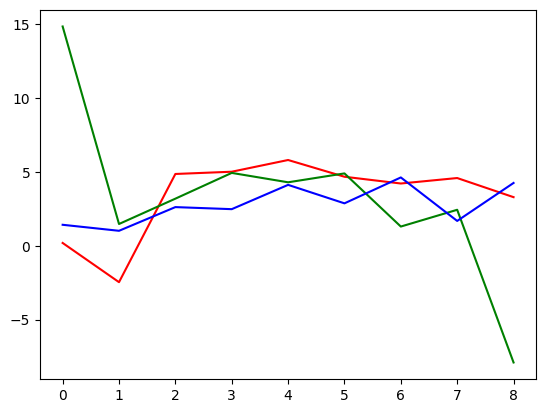

In [337]:
widths = np.sqrt(second_moment(vert_psfs[:,:,:,:,1,:], axis=4))

def find_focused_points(psfs):
    widths = np.sqrt(second_moment(psfs[:,:,:,:,1,:], axis=4))
    x = np.arange(widths.shape[1])
    minima = np.array(
        [
            [
                [
                    parabolic_minimum_fit(x, widths[k,:,i,colour]) 
                    for colour in range(3)
                ] for i in range(widths.shape[2])
            ] for k in range(widths.shape[0])
        ]
    )
    return minima

minima = find_focused_points(vert_psfs)

peaks = np.argmin(widths[0,...], axis=0)
plt.plot(minima[0,:,0], color="red")
plt.plot(minima[0,:,1], color="green")
plt.plot(minima[0,:,2], color="blue")


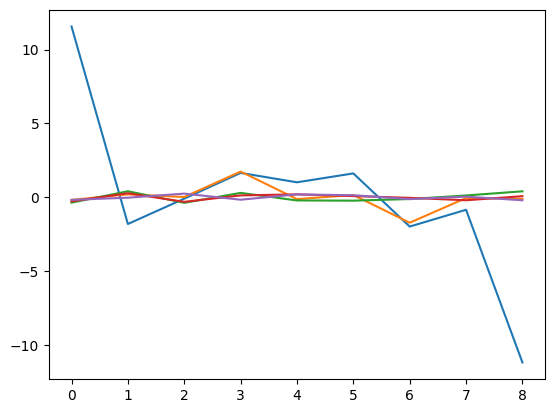

In [338]:
plt.plot(minima[:,:,1].T - np.mean(minima[:,:,1], axis=1)[:,np.newaxis].T)

nan nan


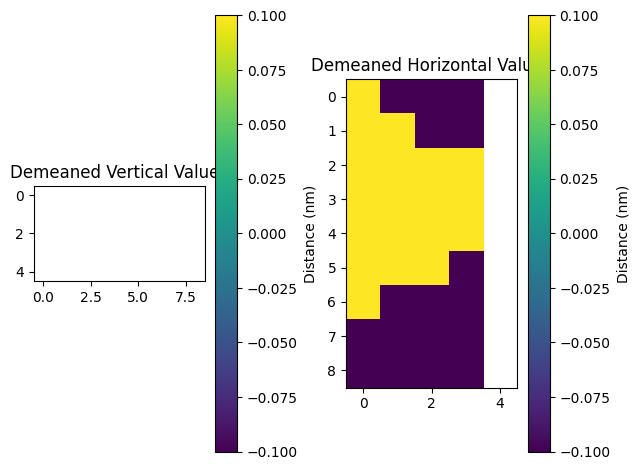

In [339]:
from scipy.interpolate import interp1d

dz = 10  
step_to_nm = 50

v_minima = find_focused_points(vert_psfs) # 5 (stacks) x 9 (ROIs) x 3 (colour channels)
h_minima = find_focused_points(horiz_psfs)

demeaned_v = v_minima[:,:,1] - np.mean(v_minima[:,:,1], axis=1)[:,np.newaxis]
demeaned_h = h_minima[:,:,1] - np.mean(h_minima[:,:,1], axis=1)[:,np.newaxis]

mean_v = np.mean(v_minima[:,:,1], axis=0)
mean_v -= np.mean(mean_v)
mean_h = np.mean(h_minima[:,:,1], axis=0)
mean_h -= np.mean(mean_h)

line_positions = np.linspace(0.1, 0.9, 5)
chunk_positions = np.linspace(1/18, 19/18, 9)

mean_h_f = interp1d(chunk_positions, mean_h, kind="linear")
mean_v_f = interp1d(chunk_positions, mean_v, kind="linear")

demeaned_v += mean_h_f(line_positions)[:, np.newaxis]
demeaned_h += mean_v_f(line_positions)[:, np.newaxis]

field_curvature_v = demeaned_v * dz * step_to_nm
field_curvature_h = demeaned_h * dz * step_to_nm

min_val = min(np.min(field_curvature_v), np.min(field_curvature_h))
max_val = max(np.max(field_curvature_v), np.max(field_curvature_h))
print(min_val,max_val)
f, ax = plt.subplots(1,2)
im1 = ax[0].imshow(field_curvature_v, vmin=min_val, vmax=max_val)
ax[0].set_title('Demeaned Vertical Values')
plt.colorbar(im1, ax=ax[0],label='Distance (nm)')

im2 = ax[1].imshow(field_curvature_h.T, vmin=min_val, vmax=max_val)
ax[1].set_title('Demeaned Horizontal Values')
plt.colorbar(im2, ax=ax[1],label='Distance (nm)')

plt.tight_layout()
plt.show()

In [340]:
def plot_field_curvature(widths):
    plt.imshow(widths[:,:,1])
    x = np.arange(widths.shape[0])
    minima = np.array([parabolic_minimum_fit(x, widths[:,i,1]) for i in range(widths.shape[1])])

    plt.plot(minima)
    plt.colorbar()
    plt.show()
    plt.close()

#plot_field_curvature(widths)

In [341]:
'''
f, ax = plt.subplots(3,3)
axes = np.array(ax).flatten()

minima = np.empty((widths.shape[1],))
for i in range(widths.shape[1]):
    x = np.arange(widths.shape[0])
    axes[i].plot(widths[:,i,1], 'o')
    minima[i] = parabolic_minimum_fit(x, widths[:,i,1], plot_ax=axes[i])

minima2 = np.array([parabolic_minimum_fit(x, widths[:,i,1]) for i in range(widths.shape[1])])
'''

"\nf, ax = plt.subplots(3,3)\naxes = np.array(ax).flatten()\n\nminima = np.empty((widths.shape[1],))\nfor i in range(widths.shape[1]):\n    x = np.arange(widths.shape[0])\n    axes[i].plot(widths[:,i,1], 'o')\n    minima[i] = parabolic_minimum_fit(x, widths[:,i,1], plot_ax=axes[i])\n\nminima2 = np.array([parabolic_minimum_fit(x, widths[:,i,1]) for i in range(widths.shape[1])])\n"

In [342]:
'''
y = widths[:,7,1]
s = bottom_slice(y)
p = np.polynomial.Polynomial.fit(x[s], y[s], 2)
p.deriv(1).roots()

plt.plot(x, y, 'o')
xx = np.linspace(x.min(), x.max(), 100)
plt.plot(x, p(x))
plt.axvline(p.deriv(1).roots()[0])
'''

"\ny = widths[:,7,1]\ns = bottom_slice(y)\np = np.polynomial.Polynomial.fit(x[s], y[s], 2)\np.deriv(1).roots()\n\nplt.plot(x, y, 'o')\nxx = np.linspace(x.min(), x.max(), 100)\nplt.plot(x, p(x))\nplt.axvline(p.deriv(1).roots()[0])\n"

vert plots



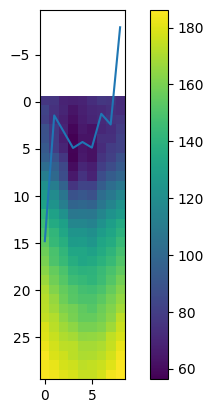

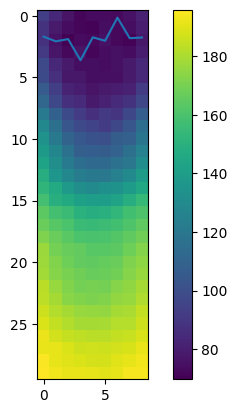

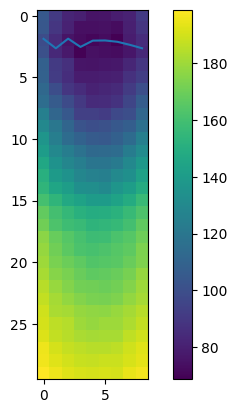

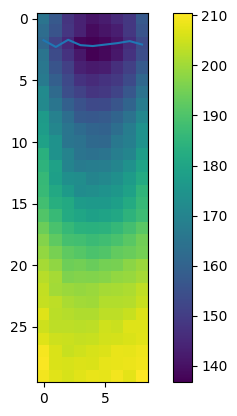

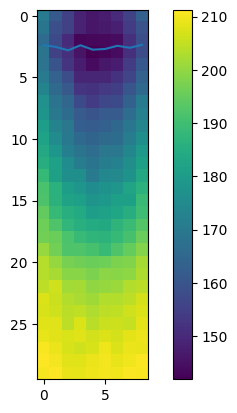

horiz plots



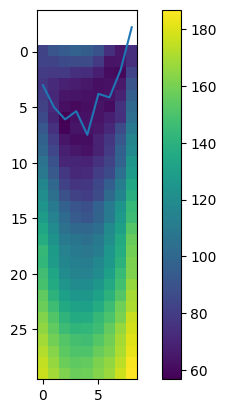

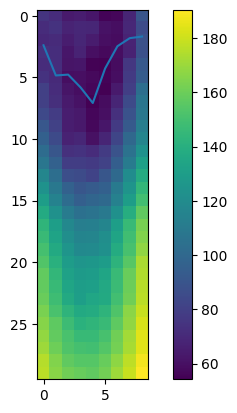

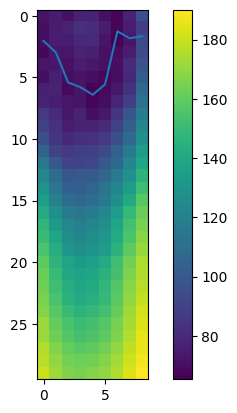

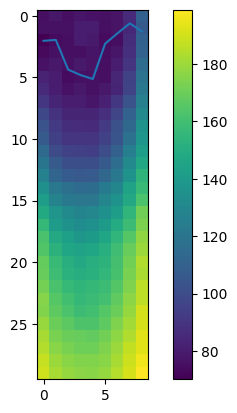

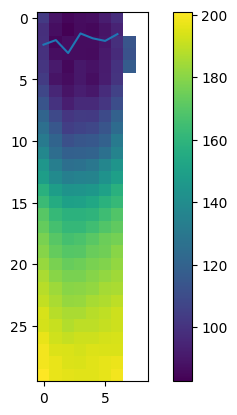

In [343]:

for direction in ['vert', 'horiz']:
    print(f"{direction} plots")
    directional_psfs = load_folders(all_paths[direction])
    for index in range(np.size(directional_psfs,axis=0)):
        print()
        widths = np.sqrt(second_moment(directional_psfs[index,:,:,:,1,:], axis=3))
        peaks = np.argmin(widths, axis=0)
        plot_field_curvature(widths)
        
